In [10]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import importlib
import lib.dls as dls

In [11]:
with h5py.File('gencarr_transpose.h5', 'r') as f:
    print(f.keys())
    data = f['UV'][0]
    mean = f['mean'][:]
    x_grid = f['x_grid'][:]
    y_grid = f['y_grid'][:]
    z_grid = f['z_grid'][:]
    print(f['UV'].shape)
    print( f['mean'].shape)

<KeysViewHDF5 ['UV', 'mean', 'x_grid', 'y_grid', 'z_grid']>
(600, 542, 85, 43, 3)
(542, 85, 43, 3)


In [12]:
data_path = 'gencarr_transpose.h5'
field_name = 'UV'
latent_path = 'latent.h5'
patch_size = 19
num_modes = 10
batch_size = 10

importlib.reload(dls)
# latent_config = dls.gfem_3d_long(data_path, field_name, latent_path, patch_size, num_modes, batch_size)

<module 'lib.dls' from '/mnt/CalebDrive/cmorton/carrier_dls/lib/dls.py'>

In [13]:
from lib.dls_flexible import *

In [14]:
with h5py.File('gencarr_transpose.h5', 'r') as f:
    data_mem = {
        "q": f['UV'][:2],          # [num_snaps, nx, ny, nz, 3]
        "mean": f['mean'][:],    # [nx, ny, nz, 3]
        "x_grid": f['x_grid'][:],
        "y_grid": f['y_grid'][:],
        "z_grid": f['z_grid'][:],
    }

latent_config, dof_u, dof_v, dof_w = gfem_3d_long_flexible(
    data_source=data_mem,
    field_name="q",
    patch_size=19,
    num_modes=10,
    latent_target=None,
    batch_size=1,
)



shape of mode data: (542, 85, 43, 3)
number of snapshots: 2
number of batches: 2
nx: 542
ny: 85
num_vars: 3
Performing modal decomposition to get local modes
NYI ----- Data shape: (542, 85, 43), treating as tall for SVD
NYI ----- Data shape: (542, 85, 43), treating as tall for SVD
NYI ----- Data shape: (542, 85, 43), treating as tall for SVD
Modal decomposition done
Constructing local modal matrices
Local modal matrices constructed
Constructing global M GFEM matrices
Prefactorizing M
M prefactorized
Looping through snapshots, solving for dofs


100%|██████████| 2/2 [00:07<00:00,  3.77s/it]


Solved for dofs in 7.53 seconds


(1000, 88)


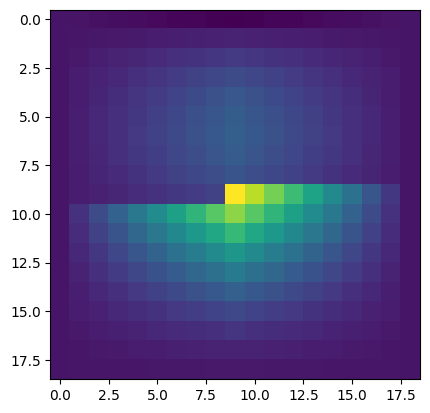

In [20]:
print(latent_config.modemat_local_u.shape)
nskip = patch_size // 2
shape_funcs = latent_config.modemat_local_u
dims = shape_funcs.shape
shape_funcs = shape_funcs.reshape(nskip+1, nskip+1, nskip+1, -1, order='F')
shape_func_reshaped = np.zeros((patch_size, patch_size, patch_size, num_modes+1), dtype=shape_funcs.dtype)
mid_pt = patch_size // 2 + 1

F1 = list(range(0, mid_pt))
F2= list(range(mid_pt - 1, patch_size))
F4 = list(range(0, mid_pt))
F3 = list(range(mid_pt - 1, patch_size))
F6 = list(range(0, mid_pt))
F5 = list(range(mid_pt - 1, patch_size))

comp1_x, comp1_y, comp1_z = np.meshgrid(F2, F3, F6, indexing='ij')
comp2_x, comp2_y, comp2_z = np.meshgrid(F2, F4, F6, indexing='ij')
comp3_x, comp3_y, comp3_z = np.meshgrid(F2, F4, F5, indexing='ij')
comp4_x, comp4_y, comp4_z = np.meshgrid(F2, F3, F5, indexing='ij')
comp5_x, comp5_y, comp5_z = np.meshgrid(F1, F3, F6, indexing='ij')
comp6_x, comp6_y, comp6_z = np.meshgrid(F1, F4, F6, indexing='ij')
comp7_x, comp7_y, comp7_z = np.meshgrid(F1, F4, F5, indexing='ij')
comp8_x, comp8_y, comp8_z = np.meshgrid(F1, F3, F5, indexing='ij')

for i in range(num_modes+1):
    shape_func_reshaped[comp1_x, comp1_y, comp1_z, i] = shape_funcs[..., i]
    shape_func_reshaped[comp2_x, comp2_y, comp2_z, i] = shape_funcs[..., i+(num_modes+1)]
    shape_func_reshaped[comp3_x, comp3_y, comp3_z, i] = shape_funcs[..., i+2*(num_modes+1)]
    shape_func_reshaped[comp4_x, comp4_y, comp4_z, i] = shape_funcs[..., i+3*(num_modes+1)]
    shape_func_reshaped[comp5_x, comp5_y, comp5_z, i] = shape_funcs[..., i+4*(num_modes+1)]
    shape_func_reshaped[comp6_x, comp6_y, comp6_z, i] = shape_funcs[..., i+5*(num_modes+1)]
    shape_func_reshaped[comp7_x, comp7_y, comp7_z, i] = shape_funcs[..., i+6*(num_modes+1)]
    shape_func_reshaped[comp8_x, comp8_y, comp8_z, i] = shape_funcs[..., i+7*(num_modes+1)]

plt.imshow(shape_func_reshaped[mid_pt, :, :, 0])

In [16]:
Q_rec = gfem_recon_long_3D_flexible(
    rec_target=None,
    config=latent_config,
    dof_u=dof_u,
    dof_v=dof_v,
    dof_w=dof_w,
    batch_size=2,
)

Processing batch 1/1, batch size: 2, processed in 0.37s
Total reconstruction time not with saving to disk: 396.56s



In [17]:
print(Q_rec.shape)
x_trunc = x_grid[:latent_config.nx_t, :latent_config.ny_t, :latent_config.nz_t]
y_trunc = y_grid[:latent_config.nx_t, :latent_config.ny_t, :latent_config.nz_t]
z_trunc = z_grid[:latent_config.nx_t, :latent_config.ny_t, :latent_config.nz_t]
# plt.contourf(x_trunc[:,:,15], y_trunc[:,:,15], Q_rec[0, :, :, 15, 0], levels=200)

(2, 541, 82, 37, 3)


2026-04-27 12:03:44.225 ( 179.376s) [    757A33D26080]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=
/tmp/ipykernel_145955/1130592282.py:29: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  pl.show()


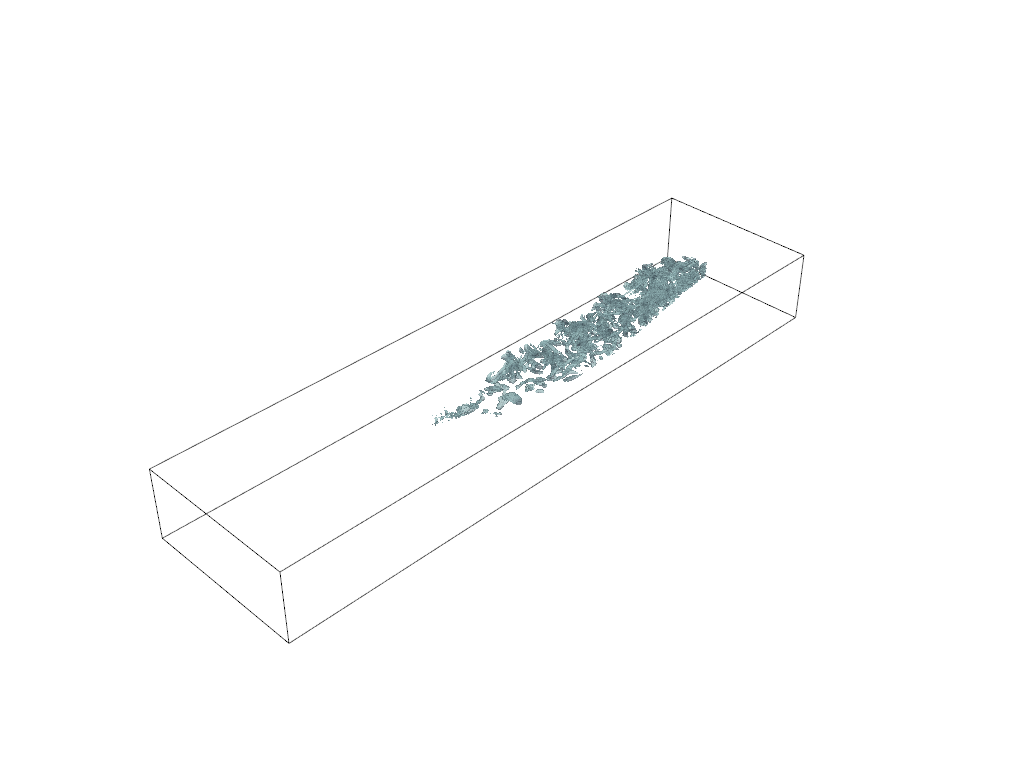

/tmp/ipykernel_145955/1130592282.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  pl.show()


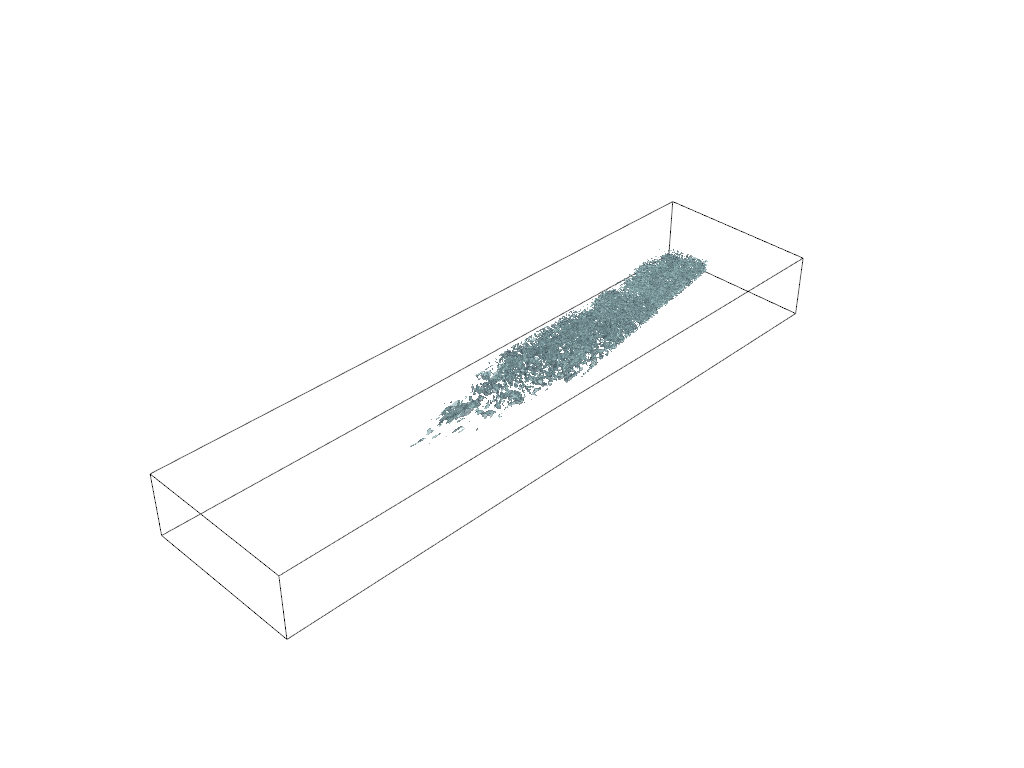

In [18]:
# 1. Create a grid and add velocity data
grid = pv.StructuredGrid(x_grid, y_grid, z_grid)
# PyVista point data must be sized as (n_points,) or (n_points, 3)

grid['velocity'] = data.reshape(-1, 3, order='F')

# 2. Compute the velocity gradient tensor
# This returns a (N, 9) array of derivatives [dudx, dudy, dudz, dvdx, ...]
grad = grid.compute_derivative(scalars='velocity', gradient=True)
g = grad['gradient'].reshape(-1, 3, 3)

# 3. Calculate Q-criterion
# S = 0.5 * (g + g.T), Omega = 0.5 * (g - g.T)
S = 0.5 * (g + g.transpose(0, 2, 1))
Omega = 0.5 * (g - g.transpose(0, 2, 1))

# Q = 0.5 * (||Omega||^2 - ||S||^2)
# Using Frobenius norm: sum of squares of components
q_val = 0.5 * (np.sum(Omega**2, axis=(1, 2)) - np.sum(S**2, axis=(1, 2)))
grid['Q-criterion'] = q_val

# 4. Plot Isosurface
# Choose a small positive value for Q to visualize the vortex cores
contour = grid.contour(isosurfaces=[0.01], scalars='Q-criterion')

pl = pv.Plotter()
pl.add_mesh(contour, color='lightblue', opacity=0.7)
pl.add_mesh(grid.outline(), color='black')
pl.show()

# plot q criterion isosurface of reconstructed field
grid_rec = pv.StructuredGrid(x_trunc, y_trunc, z_trunc)
grid_rec['velocity'] = Q_rec[0].reshape(-1, 3, order='F')
# 2. Compute the velocity gradient tensor
# This returns a (N, 9) array of derivatives [dudx, dudy, dudz, dvdx, ...]
grad = grid_rec.compute_derivative(scalars='velocity', gradient=True)
g = grad['gradient'].reshape(-1, 3, 3)

# 3. Calculate Q-criterion
# S = 0.5 * (g + g.T), Omega = 0.5 * (g - g.T)
S = 0.5 * (g + g.transpose(0, 2, 1))
Omega = 0.5 * (g - g.transpose(0, 2, 1))

# Q = 0.5 * (||Omega||^2 - ||S||^2)
# Using Frobenius norm: sum of squares of components
q_val = 0.5 * (np.sum(Omega**2, axis=(1, 2)) - np.sum(S**2, axis=(1, 2)))
grid_rec['Q-criterion'] = q_val

# 4. Plot Isosurface
# Choose a small positive value for Q to visualize the vortex cores
contour = grid_rec.contour(isosurfaces=[0.01], scalars='Q-criterion')

pl = pv.Plotter()
pl.add_mesh(contour, color='lightblue', opacity=0.7)
pl.add_mesh(grid_rec.outline(), color='black')
pl.show()